In [2]:
import pandas as pd
import glob
import os

os.chdir(r"C:\Users\DELL\Desktop\aqi-project")

# Load CSV
csv_files = glob.glob("data/raw/*.csv")
df = pd.read_csv(csv_files[-1])

# Fix date column (use whatever column name worked in Day 4)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df = df.sort_values('datetime')

print(f"Loaded {len(df)} rows")
print(df['parameter'].value_counts())

Loaded 94 rows
parameter
pm25                20
pm1                 18
relativehumidity    18
temperature         18
um003               18
pm10                 2
Name: count, dtype: int64


In [4]:
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.groupby('parameter')['value'].describe().round(2))

=== Missing Values ===
datetime       0
parameter      0
value          0
unit           0
location_id    0
location       0
latitude       0
longitude      0
dtype: int64

=== Basic Statistics ===
                  count     mean      std     min      25%      50%      75%  \
parameter                                                                      
pm1                18.0   116.90   402.48    9.80    15.60    21.95    28.00   
pm10                2.0    82.67     6.22   78.27    80.47    82.67    84.87   
pm25               20.0   121.34   379.96   19.50    25.82    32.70    43.88   
relativehumidity   18.0    51.41    10.66   31.46    47.25    52.50    56.75   
temperature        18.0    26.42     2.96   21.80    24.72    26.00    28.02   
um003              18.0  2261.44  2279.15  746.00  1041.00  1586.50  2388.65   

                      max  
parameter                  
pm1               1729.30  
pm10                87.07  
pm25              1734.60  
relativehumidity    7

In [5]:
# Remove negative values (sensor errors)
before = len(df)
df = df[df['value'] >= 0]
after = len(df)
print(f"Removed {before - after} negative readings")

# Remove extreme outliers (values above 99th percentile)
def remove_outliers(group):
    q99 = group['value'].quantile(0.99)
    return group[group['value'] <= q99]

df = df.groupby('parameter', group_keys=False).apply(remove_outliers)
print(f"Rows after cleaning: {len(df)}")

Removed 0 negative readings
Rows after cleaning: 88


In [13]:
# Calculate daily average directly (no parameter grouping needed)
daily_avg = df.groupby('day')['value'].mean().reset_index()
daily_avg.columns = ['day', 'avg_value']
daily_avg['avg_value'] = daily_avg['avg_value'].round(2)

print("Daily PM2.5 averages:")
print(daily_avg)

Daily PM2.5 averages:
          day  avg_value
0  2025-01-13      78.27
1  2025-03-24      71.00
2  2026-01-27     544.97
3  2026-04-06      40.55
4  2026-05-11     180.70
5  2026-05-20     443.25
6  2026-06-01    1559.10
7  2026-06-04     601.10
8  2026-06-09     298.52


In [15]:
def pm25_to_aqi(pm25):
    """Convert PM2.5 concentration to AQI using US EPA formula."""
    breakpoints = [
        (0.0,   12.0,   0,   50),
        (12.1,  35.4,  51,  100),
        (35.5,  55.4, 101,  150),
        (55.5, 150.4, 151,  200),
        (150.5, 250.4, 201, 300),
        (250.5, 350.4, 301, 400),
        (350.5, 500.4, 401, 500),
    ]
    for pm_low, pm_high, aqi_low, aqi_high in breakpoints:
        if pm_low <= pm25 <= pm_high:
            aqi = ((aqi_high - aqi_low) / (pm_high - pm_low)) * \
                  (pm25 - pm_low) + aqi_low
            return round(aqi)
    return 500

def aqi_category(aqi):
    """Return health category for an AQI value."""
    if aqi <= 50:   return "Good 🟢"
    if aqi <= 100:  return "Moderate 🟡"
    if aqi <= 150:  return "Unhealthy for Sensitive Groups 🟠"
    if aqi <= 200:  return "Unhealthy 🔴"
    if aqi <= 300:  return "Very Unhealthy 🟣"
    return "Hazardous ⚫"

print("Functions defined!")

Functions defined!


In [16]:
daily_avg['aqi'] = daily_avg['avg_value'].apply(pm25_to_aqi)
daily_avg['category'] = daily_avg['aqi'].apply(aqi_category)

print("\n=== Kathmandu AQI Results ===")
print(daily_avg[['day', 'avg_value', 'aqi', 'category']].to_string(index=False))


=== Kathmandu AQI Results ===
       day  avg_value  aqi                         category
2025-01-13      78.27  163                      Unhealthy 🔴
2025-03-24      71.00  159                      Unhealthy 🔴
2026-01-27     544.97  500                      Hazardous ⚫
2026-04-06      40.55  113 Unhealthy for Sensitive Groups 🟠
2026-05-11     180.70  231                 Very Unhealthy 🟣
2026-05-20     443.25  462                      Hazardous ⚫
2026-06-01    1559.10  500                      Hazardous ⚫
2026-06-04     601.10  500                      Hazardous ⚫
2026-06-09     298.52  349                      Hazardous ⚫


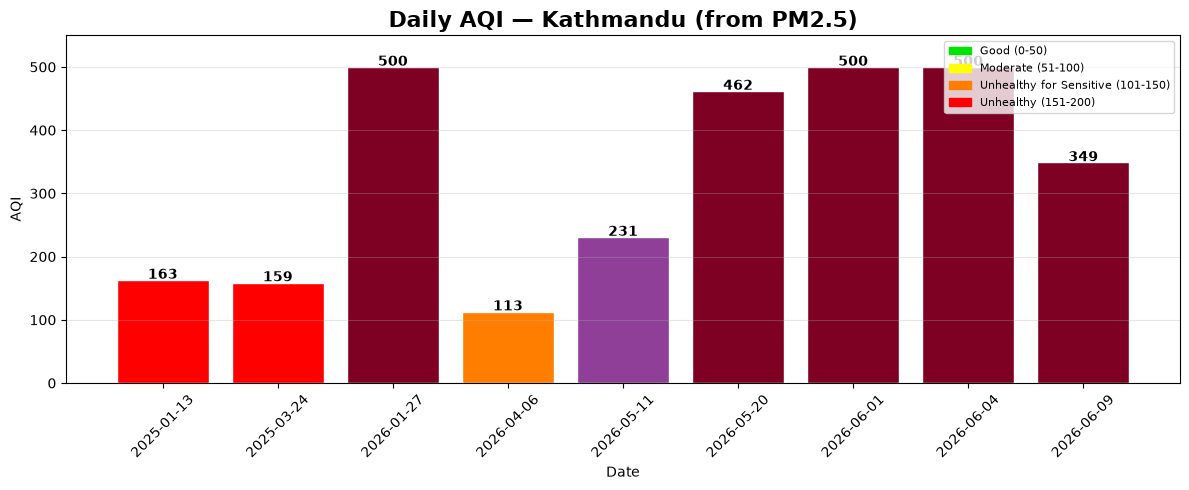

AQI chart saved!


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5))

# Color each bar by AQI category
colors = []
for aqi in daily_avg['aqi']:
    if aqi <= 50:    colors.append('#00e400')
    elif aqi <= 100: colors.append('#ffff00')
    elif aqi <= 150: colors.append('#ff7e00')
    elif aqi <= 200: colors.append('#ff0000')
    elif aqi <= 300: colors.append('#8f3f97')
    else:            colors.append('#7e0023')

bars = ax.bar(daily_avg['day'].astype(str), 
              daily_avg['aqi'], color=colors, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, daily_avg['aqi']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Daily AQI — Kathmandu (from PM2.5)', 
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.set_ylim(0, max(daily_avg['aqi'].max() + 50, 200))
plt.xticks(rotation=45)

# Legend
legend = [
    mpatches.Patch(color='#00e400', label='Good (0-50)'),
    mpatches.Patch(color='#ffff00', label='Moderate (51-100)'),
    mpatches.Patch(color='#ff7e00', label='Unhealthy for Sensitive (101-150)'),
    mpatches.Patch(color='#ff0000', label='Unhealthy (151-200)'),
]
ax.legend(handles=legend, loc='upper right', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('data/raw/aqi_chart.png', dpi=150)
plt.show()
print("AQI chart saved!")